Парная линейная регрессия
Цель работы
    Познакомиться с моделью парной линейной регрессии регрессии и методом градиентного спуска.

Содержание работы
Найти оценки параметров модели парной линейной регрессии прямыми вычислениями и палучить с помощью модели прогнозы результативного прознака.
Найти оценки параметров модели парной линейной регрессии с использованием метода градиентного спуска.
Оценить качество построенной модели, сравнив на графике обучающую выборку и прогнозы.
Построить кривые обучения.

In [3]:
#Загрузим необходимые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Исходные данные: x - расходы на рекламу, Y - объемы продаж
x = np.array([3, 5, 7, 6, 9])
Y = np.array([3, 7, 11, 14, 15])
display(x, Y)

array([3, 5, 7, 6, 9])

array([ 3,  7, 11, 14, 15])

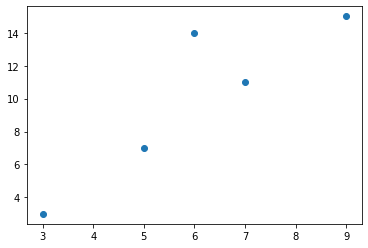

In [5]:
#Изобразим их на графике
plt.figure()
plt.scatter(x, Y)
plt.show()

In [6]:
#Вычислим оценки коэффициентов парной линейной регрессии по формулам
a1 = ((x - x.mean())*(Y - Y.mean())).mean()/((x - x.mean())**2).mean()
a0 = Y.mean() - a1*x.mean()
print("Модель линейной регрессии: Y^ = ", a0, " + ", a1, "* x")

Модель линейной регрессии: Y^ =  -2.0  +  2.0 * x


In [7]:
#Дадим серию прогнозов Y^ для x от 3 до 9 с шагом 1
x_space = np.linspace(3, 9, 7)
print(x_space)
Y_pred = a0 + a1*x_space
print(Y_pred)

[3. 4. 5. 6. 7. 8. 9.]
[ 4.  6.  8. 10. 12. 14. 16.]


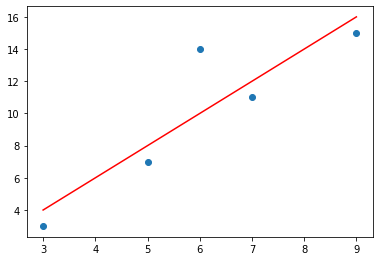

In [8]:
#Изобразим на графике исходные данные и прогнозы 
fig  = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')
#ax.scatter(x_space, Y_pred)

In [9]:
#Реализуем шаг градиентного спуска в модели парной лдинейной регрессии
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((self.predict(x)-Y)**2).mean()
    def fit(self, x, Y):
        alpha = 0.1
        dT_a0 = -2*sum((Y -self.predict(x)))
        dT_a1 = -2*sum((Y -self.predict(x))*x)
        self.a0 -= alpha*dT_a0
        self.a1 -= alpha*dT_a1

In [10]:
#Получим прогнозы до градиентного спуска с начальными значениями параметров
regr = SimpleRegression()
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print(regr.MSE(x, Y))

0
0
0
0
0
120.0


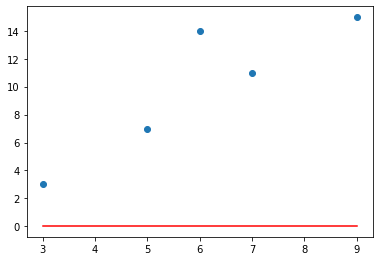

In [119]:
#Выведем прогнозы до градиентного спуска на графике
x_space = np.linspace(3, 9, 7)
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

MSE после первого шага градиентного спуска:  183892.0


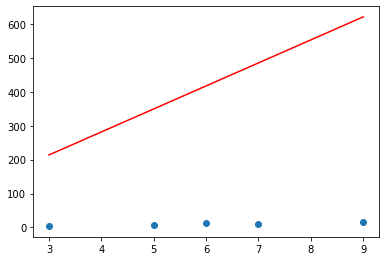

In [120]:
#Реализуем шаг градиентного спуска
regr.fit(x, Y)
print("MSE после первого шага градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

In [164]:
#Реализуем цикл градиентного спуска
class SimpleRegression(object):
    def __init__(self):
        self.a0 = 0
        self.a1 = 0
    def predict(self, x):
        return self.a0 + self.a1*x
    def MSE(self, x, Y):
        return ((Y - self.predict(x))**2).mean()
    def MAE(self, x, Y):
        return abs(Y - self.predict(x)).mean()
    def MAPE(self, x, Y):
        return abs((Y - self.predict(x))/Y).mean()
    def fit(self, x, Y, alpha = 0.001, epsylon = 0.01, max_steps = 5000):
        steps, errors = [], []
        step = 0
        for _ in range(max_steps):
            dT_a0 = -2*sum((Y -self.predict(x)))
            dT_a1 = -2*sum((Y -self.predict(x))*x)
            self.a0 -= alpha*dT_a0
            self.a1 -= alpha*dT_a1
            new_error = self.MSE(x, Y)
            step += 1
            steps.append(step)
            errors.append(new_error)
            if new_error < epsylon:
                break
        return steps, errors

In [165]:
#Запустим цикл градиентного спуска с заданной точностью 5
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 5)

5.004697916218
8.190462542210001
11.376227168202002
9.783344855206002
14.561991794194002
MSE после градиентного спуска:  4.709918696051655


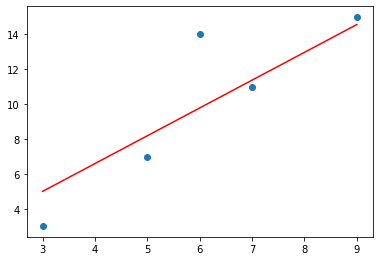

In [166]:
#Выведем график  прогнозов и вычислим MSE
print(regr.predict(3))
print(regr.predict(5))
print(regr.predict(7))
print(regr.predict(6))
print(regr.predict(9))
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

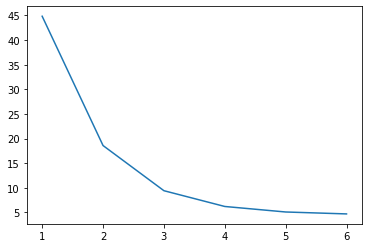

In [167]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

In [168]:
#Запустим цикл градиентного спуска с заданной точностью 0.05
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.001, epsylon = 0.05)

MSE после градиентного спуска:  4.1903709155046345


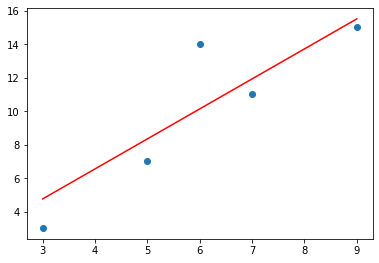

In [171]:
#Выведем график прогнозов и вычислим MSE
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.scatter(x, Y)
ax.plot(x_space, Y_pred, 'r')

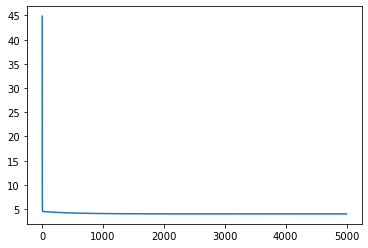

In [137]:
#Выведем график изменения MSE в процессе градиентного спуска
plt.figure()
plt.plot(steps, errors)

MSE после градиентного спуска:  4.1903709155046345


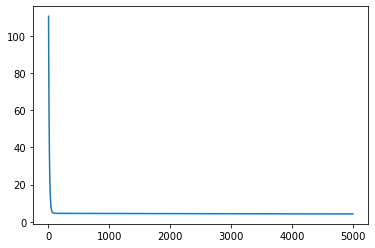

In [174]:
#Запустим цикл градиентного спуска с разными значениями скорости обучения alpha=0.0001, 0.01, 0.1, 1, 10, ..., 
#с различной допукстимой точностью epsylon = 0.001, 0.5, 5, с различным максимальным количеством шагов max_steps
regr = SimpleRegression()
steps, errors = regr.fit(x, Y, alpha = 0.0001, epsylon = 0.01, max_steps = 5000)
print("MSE после градиентного спуска: ", regr.MSE(x, Y))
Y_pred = regr.predict(x_space)
plt.figure()
plt.plot(steps, errors)

Загрузите файл Гиперспектр кукурузы.csv (с помощью pd.read_csv).

1. Вычислите аналитическим путем оценки коэффициентов парной линейной регрессии и постройте ее график.
2. Найдите оценки параметров модели парной лиенйной регрессии с использованием метода градиентного спуска. Постройте график.
3. Оцените качество построенных моделей сравнив на графике обучающую выборку и прогнозы.


Аналитический метод:
a = -0.183428
b = 0.000668
Модель: Y = -0.183428 + 0.000668X


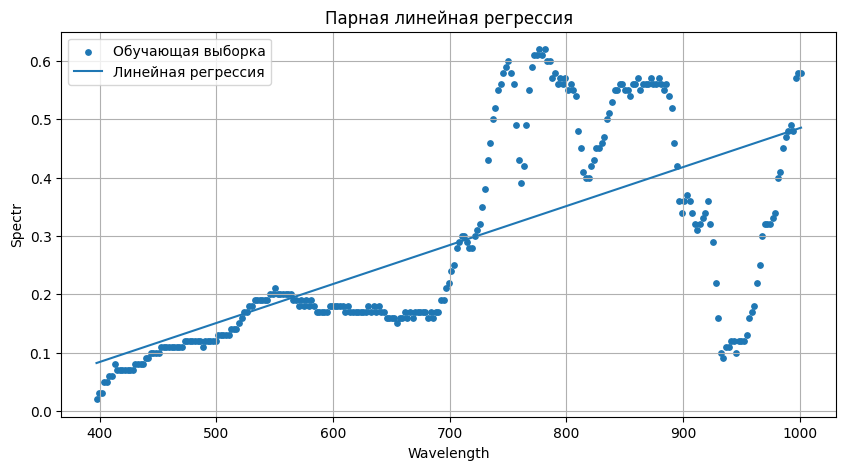


Градиентный спуск:
a = -0.183428
b = 0.000668
Модель: Y = -0.183428 + 0.000668X


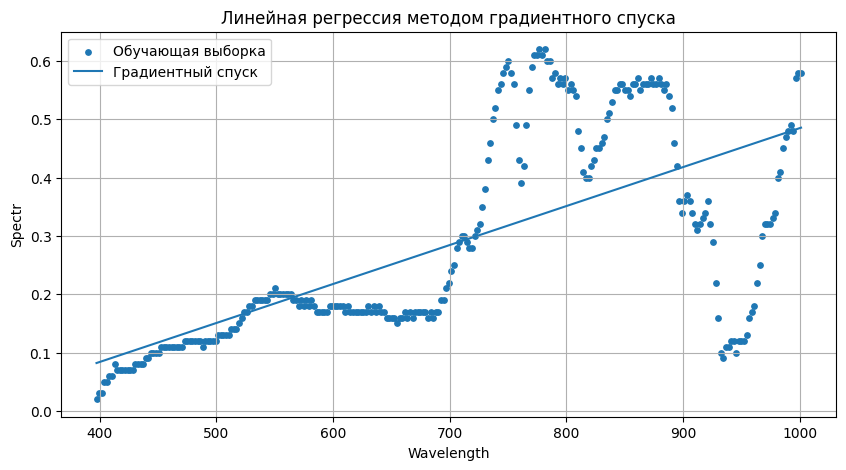


Качество моделей:
Аналитический метод: MSE = 0.017684, R² = 0.435891
Градиентный спуск:   MSE = 0.017684, R² = 0.435891


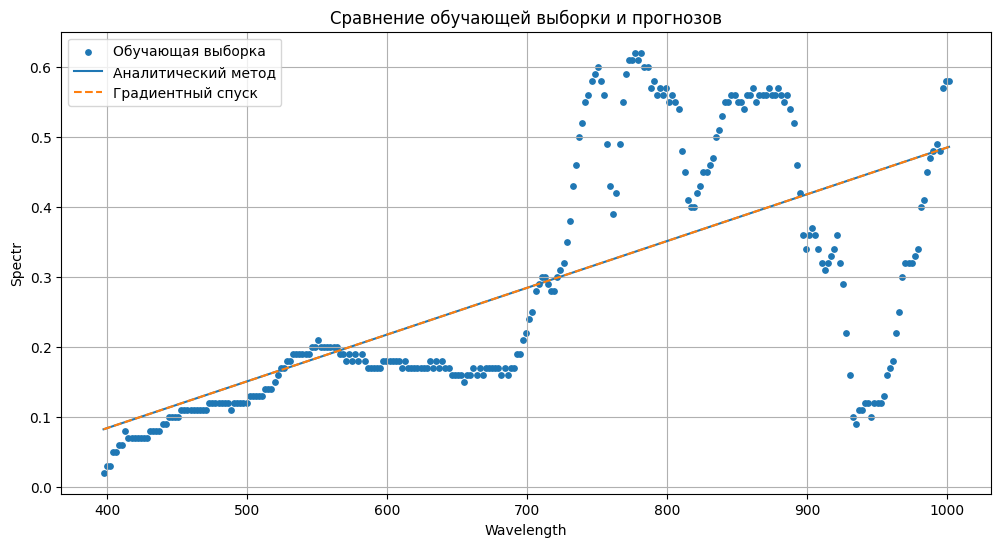

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Загрузка данных
gipers = pd.read_csv(
    r"Гиперспектр кукурузы.csv",
    sep=";",
    decimal=","
)

X = gipers["wavelength"].values
Y = gipers["Spectr"].values


# ============================================================
# 1. Аналитическая оценка коэффициентов парной регрессии
# ============================================================

x_mean = np.mean(X)
y_mean = np.mean(Y)

b = np.sum((X - x_mean) * (Y - y_mean)) / np.sum((X - x_mean) ** 2)
a = y_mean - b * x_mean

Y_analytic = a + b * X

print("Аналитический метод:")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"Модель: Y = {a:.6f} + {b:.6f}X")


plt.figure(figsize=(10, 5))
plt.scatter(X, Y, s=15, label="Обучающая выборка")
plt.plot(X, Y_analytic, label="Линейная регрессия")
plt.xlabel("Wavelength")
plt.ylabel("Spectr")
plt.title("Парная линейная регрессия")
plt.legend()
plt.grid()
plt.show()


# ============================================================
# 2. Градиентный спуск
# ============================================================

# Нормализация X
X_mean = np.mean(X)
X_std = np.std(X)
X_norm = (X - X_mean) / X_std

a_gd = 0
b_gd = 0

learning_rate = 0.01
iterations = 10000
n = len(X)

for i in range(iterations):
    Y_pred = a_gd + b_gd * X_norm

    da = (2 / n) * np.sum(Y_pred - Y)
    db = (2 / n) * np.sum((Y_pred - Y) * X_norm)

    a_gd -= learning_rate * da
    b_gd -= learning_rate * db


# Возвращаем коэффициенты к исходному X
b_gd = b_gd / X_std
a_gd = a_gd - b_gd * X_mean

Y_gd = a_gd + b_gd * X

print("\nГрадиентный спуск:")
print(f"a = {a_gd:.6f}")
print(f"b = {b_gd:.6f}")
print(f"Модель: Y = {a_gd:.6f} + {b_gd:.6f}X")


plt.figure(figsize=(10, 5))
plt.scatter(X, Y, s=15, label="Обучающая выборка")
plt.plot(X, Y_gd, label="Градиентный спуск")
plt.xlabel("Wavelength")
plt.ylabel("Spectr")
plt.title("Линейная регрессия методом градиентного спуска")
plt.legend()
plt.grid()
plt.show()


# ============================================================
# 3. Сравнение обучающей выборки и прогнозов
# ============================================================

mse_analytic = np.mean((Y - Y_analytic) ** 2)
mse_gd = np.mean((Y - Y_gd) ** 2)

r2_analytic = 1 - np.sum((Y - Y_analytic) ** 2) / np.sum((Y - y_mean) ** 2)
r2_gd = 1 - np.sum((Y - Y_gd) ** 2) / np.sum((Y - y_mean) ** 2)

print("\nКачество моделей:")
print(f"Аналитический метод: MSE = {mse_analytic:.6f}, R² = {r2_analytic:.6f}")
print(f"Градиентный спуск:   MSE = {mse_gd:.6f}, R² = {r2_gd:.6f}")


plt.figure(figsize=(12, 6))
plt.scatter(X, Y, s=15, label="Обучающая выборка")
plt.plot(X, Y_analytic, label="Аналитический метод")
plt.plot(X, Y_gd, "--", label="Градиентный спуск")
plt.xlabel("Wavelength")
plt.ylabel("Spectr")
plt.title("Сравнение обучающей выборки и прогнозов")
plt.legend()
plt.grid()
plt.show()